In [4]:
import pandas as pd
file=r"/kaggle/input/flicker8k-data/captions.txt"

In [6]:
df=pd.read_csv(file)

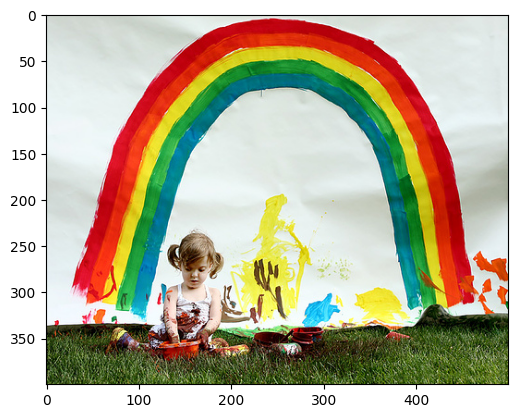

Caption: A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
Caption: A little girl is sitting in front of a large painted rainbow .
Caption: A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
Caption: There is a girl with pigtails sitting in front of a rainbow painting .


In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_idx=10
image_path=r"/kaggle/input/flicker8k-data"+ "/Images/"+df.iloc[data_idx,0]
# image_path="/kaggle/input/flicker8k-data/Images/1000268201_693b08cb0e.jpg"
img=mpimg.imread(image_path)
plt.imshow(img)
plt.show()

for i in range(data_idx,data_idx+4):
    print("Caption:",df.iloc[i,1])

In [8]:
!pip install spacy

In [9]:
import os
from collections import Counter
import spacy
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader,Dataset
import torchvision.transforms as transforms
from PIL import Image

In [10]:
spacy_eng = spacy.load("en_core_web_sm")

text="This is a good place "
[token.text.lower() for token in spacy_eng.tokenizer(text)]

['this', 'is', 'a', 'good', 'place']

In [11]:
class Vocabulary:
    def __init__(self,freq_threshold):
        self.itos = {0:"<PAD>",1:"<SOS>",2:"<EOS>",3:"<UNK>"}
        self.stoi = {v:k for k,v in self.itos.items()}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)
    
    @staticmethod
    def tokenize(text):
        return [token.text.lower() for token in spacy_eng.tokenizer(text)]
    

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        idx = 4
        
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
                
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self,text):
        tokenized_text=self.tokenize(text)
        return [ self.stoi[token] if token in self.stoi else self.stoi["<UNK>"] for token in tokenized_text ]   

In [12]:
v = Vocabulary(freq_threshold=1)

v.build_vocab(["This is a good place to find a city"])
print(v.stoi)
print(v.numericalize("This is a good place to find a city over here"))

{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, 'this': 4, 'is': 5, 'a': 6, 'good': 7, 'place': 8, 'to': 9, 'find': 10, 'city': 11}
[4, 5, 6, 7, 8, 9, 10, 6, 11, 3, 3]


In [13]:
class CaptionDataset(Dataset):

    def __init__(self,root_dir,file,transform=None,freq_threshold=4):
        self.root_dir = root_dir
        self.df = pd.read_csv(file)
        self.transform = transform

        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocab(self.captions.tolist())


    def __len__(self):
        return len(self.df)
    
    def __getitem__(self,idx):
        caption=self.captions[idx]
        img_name=self.imgs[idx]
        img_location=os.path.join(self.root_dir,img_name)
        img = Image.open(img_location).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        caption_vec = []
        caption_vec += [self.vocab.stoi["<SOS>"]]
        caption_vec += self.vocab.numericalize(caption)
        caption_vec += [self.vocab.stoi["<EOS>"]]
        
        return img, torch.tensor(caption_vec)

In [14]:
transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [15]:
def show_image(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
        

Token: tensor([  1,   4,  30,  20,   4, 100,  50,  29, 712,  63,   8,   4, 269, 219,
          5,   2])
Sentence:
['<SOS>', 'a', 'child', 'and', 'a', 'woman', 'are', 'at', 'waters', 'edge', 'in', 'a', 'big', 'city', '.', '<EOS>']


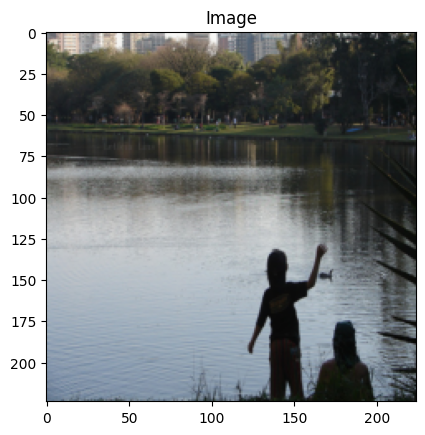

In [16]:
dataset =  CaptionDataset(
    
    root_dir=r"/kaggle/input/flicker8k-data/Images",
    file=r"/kaggle/input/flicker8k-data/captions.txt",
    transform=transforms
)


img, caps = dataset[80]
show_image(img,"Image")
print("Token:",caps)
print("Sentence:")
print([dataset.vocab.itos[token] for token in caps.tolist()])

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset,DataLoader,random_split
import torchvision.transforms as T

In [18]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(data):
    images, captions = zip(*data)
    
    images = torch.stack(images, 0)
    
    
    captions_padded = pad_sequence(captions, batch_first=True, padding_value=0)  # assuming 0 is your <PAD> index
    
    return images, captions_padded


In [19]:
data_location=r"/kaggle/input/flicker8k-data"
BATCH_SIZE=256
NUM_WORKER=4

transforms = T.Compose([
    T.Resize(226),                     
    T.RandomCrop(224),                 
    T.ToTensor(),                               
    T.Normalize((0.485, 0.456, 0.406),(0.229, 0.224, 0.225))
])


dataset =  CaptionDataset(
    root_dir = data_location+"/Images",
    file= data_location+"/captions.txt",
    transform=transforms
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)


vocab_size = len(dataset.vocab)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [20]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models

In [21]:
class EncoderCNN(nn.Module):
    def __init__(self):
        super(EncoderCNN,self).__init__()
        resnet = models.resnet50(pretrained=True)
        for param in resnet.parameters():
                    param.requires_grad_(False)  # Freeze all weights

        modules = list(resnet.children())[:-2]  # Remove avgpool + fc
        self.resnet = nn.Sequential(*modules)

    def forward(self,images):
           features=self.resnet(images)
           features=features.permute(0,2,3,1)
           features = features.view(features.size(0), -1, features.size(-1))
           return features

In [22]:
class BahdanauAttention(nn.Module):
    def __init__(self,encoder_dim,decoder_dim,attention_dim):
        super(BahdanauAttention,self).__init__()

        self.encoder_attn=nn.Linear(encoder_dim,attention_dim)
        self.decoder_attn=nn.Linear(decoder_dim,attention_dim)
        self.full_attn = nn.Linear(attention_dim, 1) 


    def forward(self,encoder_outputs,decoder_hidden):

        """
        encoder_outputs: [batch_size, seq_len, encoder_dim]
        decoder_hidden : [batch_size, decoder_dim]
        """

        encoder_proj = self.encoder_attn(encoder_outputs)           
        decoder_proj = self.decoder_attn(decoder_hidden)            
        decoder_proj = decoder_proj.unsqueeze(1)                    

        combined = torch.tanh(encoder_proj + decoder_proj)          

        scores = self.full_attn(combined).squeeze(2)                

        alpha = F.softmax(scores, dim=1)                            

        context = torch.sum(encoder_outputs * alpha.unsqueeze(2), dim=1)  

        return alpha, context
    

In [23]:
#Attention Decoder
class DecoderRNN(nn.Module):
    def __init__(self,embed_size, vocab_size, attention_dim,encoder_dim,decoder_dim,drop_prob=0.3):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.attention_dim = attention_dim
        self.decoder_dim = decoder_dim
        
        self.embedding = nn.Embedding(vocab_size,embed_size)
        self.attention = BahdanauAttention(encoder_dim,decoder_dim,attention_dim)
        
        
        self.init_h = nn.Linear(encoder_dim, decoder_dim)  
        self.init_c = nn.Linear(encoder_dim, decoder_dim)  
        self.lstm_cell = nn.LSTMCell(embed_size+encoder_dim,decoder_dim,bias=True)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        
        
        self.fcn = nn.Linear(decoder_dim,vocab_size)
        self.drop = nn.Dropout(drop_prob)

    def forward(self, features, captions):
        embeds=self.embedding(captions)
        h, c = self.init_hidden_state(features)  

        seq_length = len(captions[0])-1 
        batch_size = captions.size(0)
        num_features = features.size(1)

        preds = torch.zeros(batch_size, seq_length, self.vocab_size).to(device)
        alphas = torch.zeros(batch_size, seq_length,num_features).to(device)

        for s in range(seq_length):
            alpha,context = self.attention(features, h)
            lstm_input = torch.cat((embeds[:, s], context), dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))
                    
            output = self.fcn(self.drop(h))
            
            preds[:,s] = output
            alphas[:,s] = alpha  
        
        
        return preds, alphas
    
    def generate_caption(self,features,max_len=20,vocab=None):
        
        batch_size = features.size(0)
        h, c = self.init_hidden_state(features)  # (batch_size, decoder_dim)
        
        alphas = []
        
        #starting input
        word = torch.tensor(vocab.stoi['<SOS>']).view(1,-1).to(device)
        embeds = self.embedding(word)

        
        captions = []

        for i in range(max_len):
            alpha,context = self.attention(features, h)
            
            
            #store the apla score
            alphas.append(alpha.cpu().detach().numpy())
            
            lstm_input = torch.cat((embeds[:, 0], context), dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))
            output = self.fcn(self.drop(h))
            output = output.view(batch_size,-1)
        
            
            
            predicted_word_idx = output.argmax(dim=1)
            
            
            captions.append(predicted_word_idx.item())
            
            
            if vocab.itos[predicted_word_idx.item()] == "<EOS>":
                break

            embeds = self.embedding(predicted_word_idx.unsqueeze(0))

        return [vocab.itos[idx] for idx in captions],alphas
    
    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)  # (batch_size, decoder_dim)
        c = self.init_c(mean_encoder_out)
        return h, c


In [24]:
class EncoderDecoder(nn.Module):
    def __init__(self,embed_size, vocab_size, attention_dim,encoder_dim,decoder_dim,drop_prob=0.3):
        super().__init__()
        self.encoder = EncoderCNN()
        self.decoder = DecoderRNN(
            embed_size=embed_size,
            vocab_size = len(dataset.vocab),
            attention_dim=attention_dim,
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim
        )
        
    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

In [25]:
#Hyperparameters
embed_size=300
vocab_size = len(dataset.vocab)
attention_dim=256
encoder_dim=2048
decoder_dim=512
learning_rate = 3e-4

In [26]:
model = EncoderDecoder(
    embed_size=300,
    vocab_size = len(dataset.vocab),
    attention_dim=256,
    encoder_dim=2048,
    decoder_dim=512
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=dataset.vocab.stoi["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s] 


In [27]:
def save_model(model,num_epochs):
    model_state = {
        'num_epochs':num_epochs,
        'embed_size':embed_size,
        'vocab_size':len(dataset.vocab),
        'attention_dim':attention_dim,
        'encoder_dim':encoder_dim,
        'decoder_dim':decoder_dim,
        'state_dict':model.state_dict()
    }

    torch.save(model_state,'attention_model_state.pth')

In [28]:
!pip install nltk


In [29]:
def show_image(img,title=None):
    #unnormalize 
    img[0] = img[0] * 0.229
    img[1] = img[1] * 0.224 
    img[2] = img[2] * 0.225 
    img[0] += 0.485 
    img[1] += 0.456 
    img[2] += 0.406
    
    img = img.numpy().transpose((1, 2, 0))

    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

Epoch: 1 loss: 4.25280


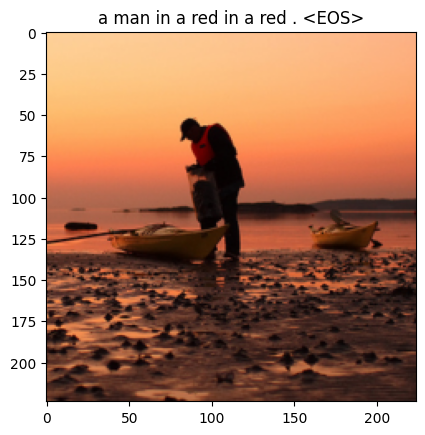

Epoch: 2 loss: 3.72505


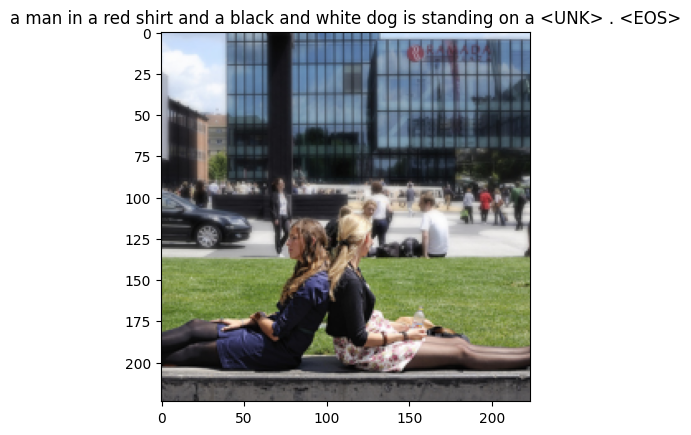

Epoch: 3 loss: 3.39340


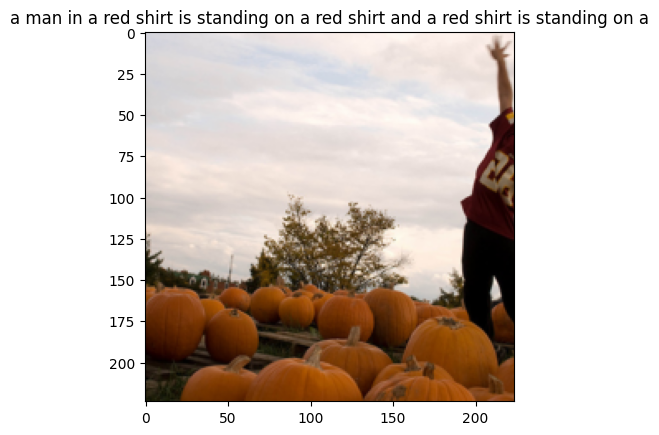

Epoch: 4 loss: 3.26721


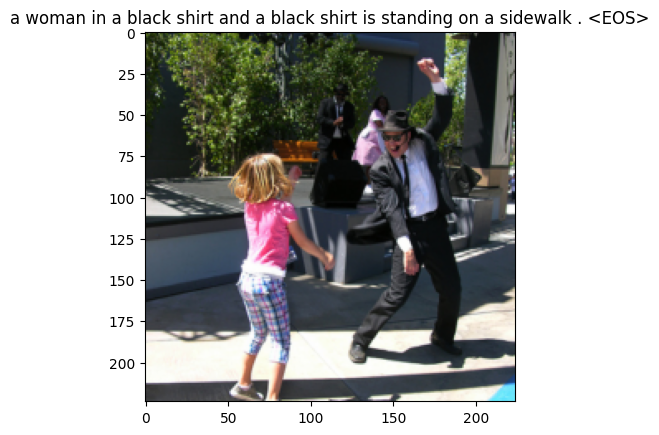

Epoch: 5 loss: 3.07554


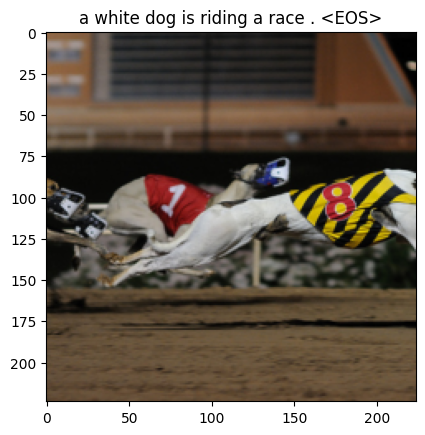

Epoch: 6 loss: 3.02901


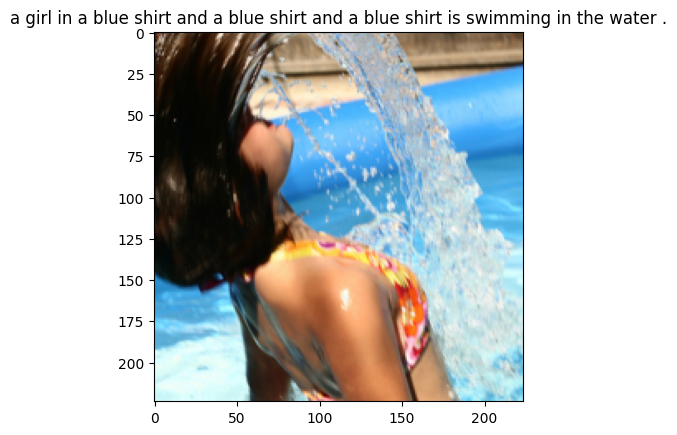

Epoch: 7 loss: 2.84614


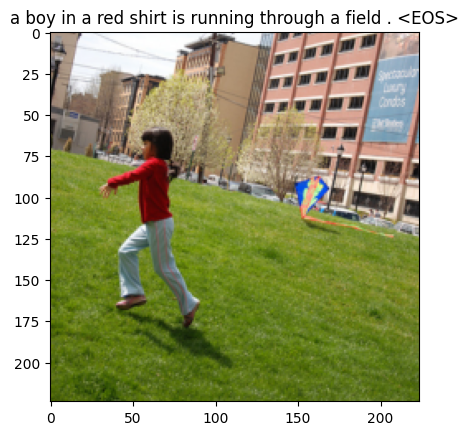

Epoch: 8 loss: 2.70458


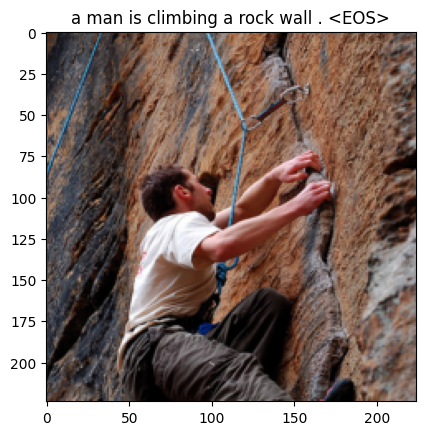

Epoch: 9 loss: 2.68126


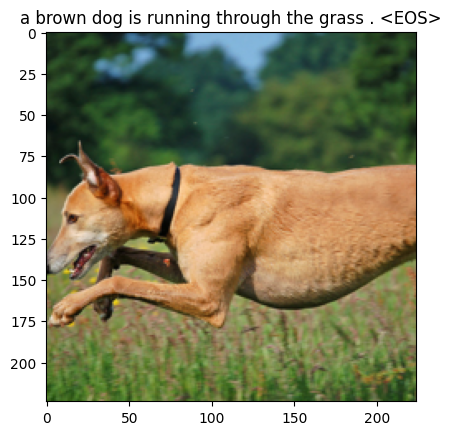

Epoch: 10 loss: 2.60630


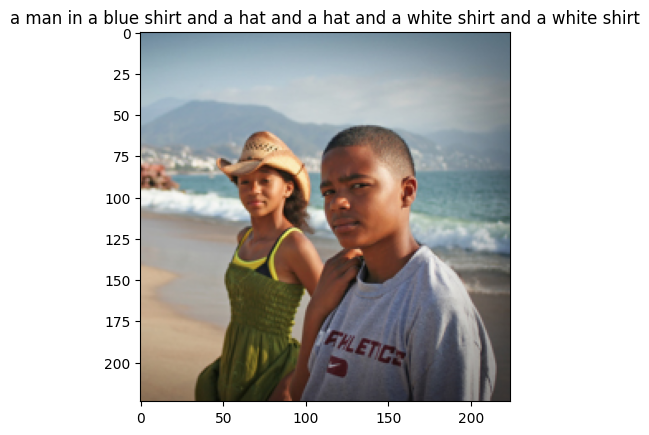

Epoch: 11 loss: 2.55804


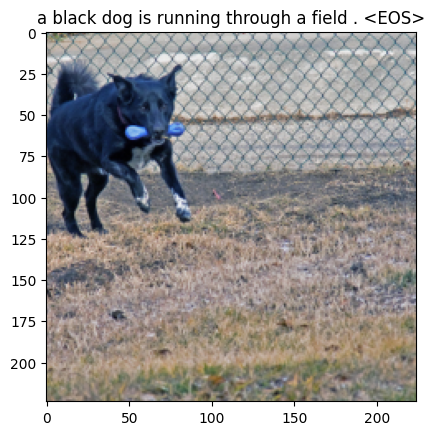

Epoch: 12 loss: 2.57335


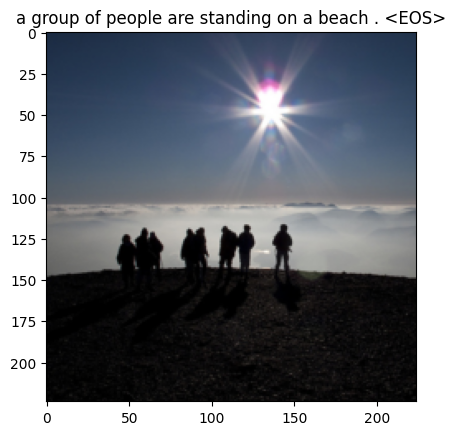

Epoch: 13 loss: 2.53332


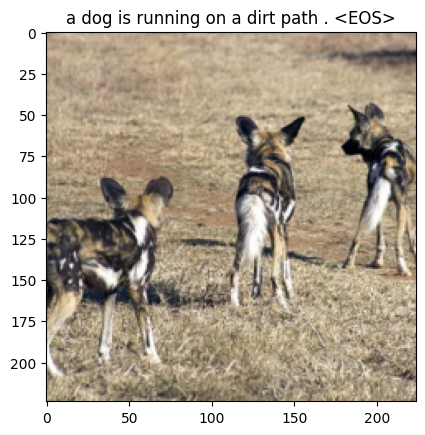

Epoch: 14 loss: 2.45190


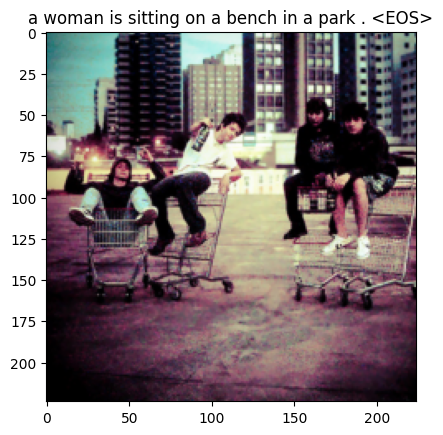

Epoch: 15 loss: 2.37838


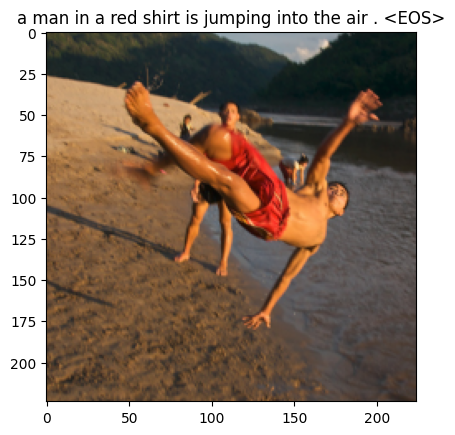

Epoch: 16 loss: 2.29888


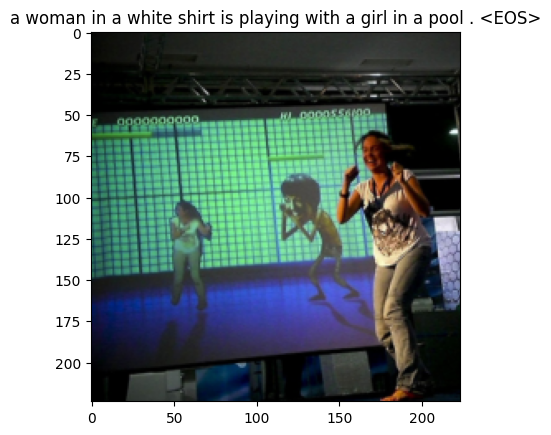

Epoch: 17 loss: 2.36708


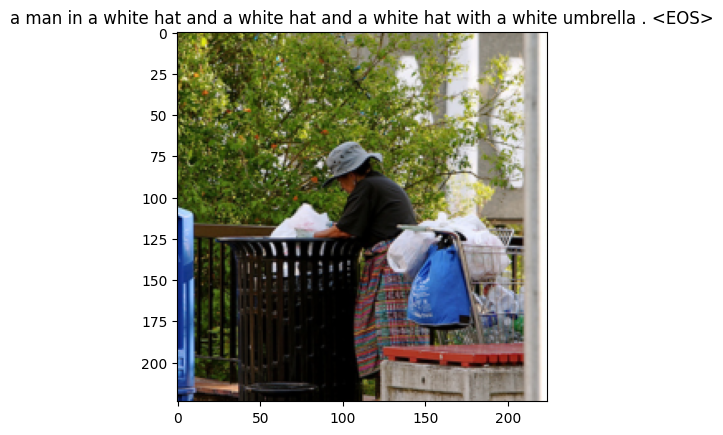

Epoch: 18 loss: 2.21796


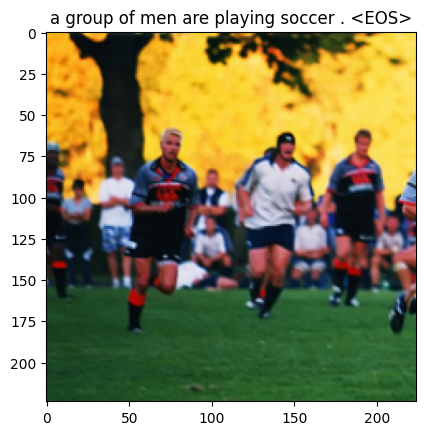

Epoch: 19 loss: 2.29069


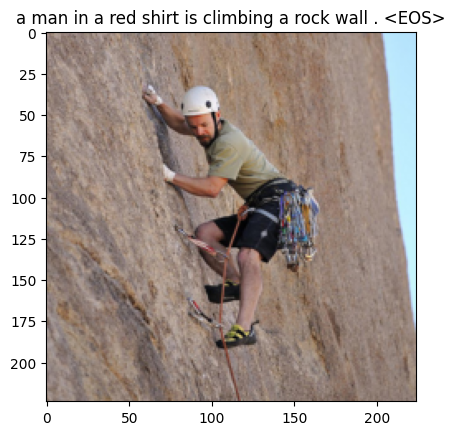

Epoch: 20 loss: 2.29681


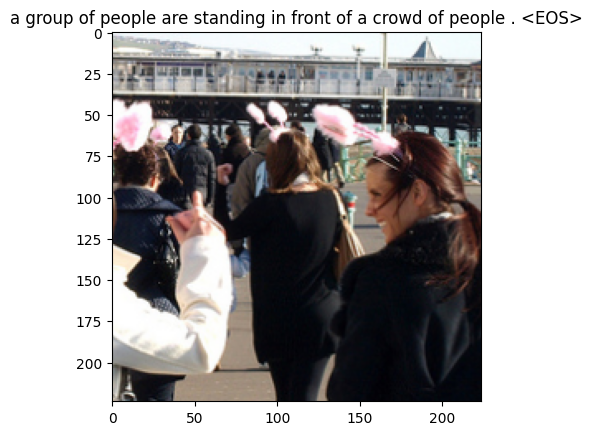

In [30]:
num_epochs=25
print_every = 100

for epoch in range(1,num_epochs+1):   
    for idx, (image, captions) in enumerate(iter(train_loader)):
        image,captions = image.to(device),captions.to(device)


        optimizer.zero_grad()

        outputs,attentions = model(image, captions)

        targets = captions[:,1:]
        loss = criterion(outputs.view(-1, vocab_size), targets.reshape(-1))

        loss.backward()
        optimizer.step()

        if (idx+1)%print_every == 0:
            print("Epoch: {} loss: {:.5f}".format(epoch,loss.item()))
            
            
            #generate the caption
            model.eval()
            with torch.no_grad():
                dataiter = iter(train_loader)
                img,_ = next(dataiter)
                features = model.encoder(img[0:1].to(device))
                caps,alphas = model.decoder.generate_caption(features,vocab=dataset.vocab)
                caption = ' '.join(caps)
                show_image(img[0],title=caption)
                
            model.train()
        
    #save the latest model
    save_model(model,epoch)






In [34]:
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

model.eval()
all_references = []
all_hypotheses = []

with torch.no_grad():
    for images, captions in tqdm(train_loader):  
        images = images.to(device)
        captions = captions.to(device)

        for i in range(images.size(0)):
            image = images[i:i+1]  
            gt_caption = captions[i]  

            features = model.encoder(image)
            predicted_tokens, _ = model.decoder.generate_caption(features, vocab=dataset.vocab)
            
            predicted_tokens = [
                tok for tok in predicted_tokens
                if tok not in ["<PAD>", "<SOS>", "<EOS>"]
            ]
            all_hypotheses.append(predicted_tokens)

            target_ids = gt_caption.tolist()
            target_tokens = []
            for idx in target_ids:
                word = dataset.vocab.itos.get(idx, "<UNK>")
                if word == "<EOS>":
                    break
                if word not in ["<PAD>", "<SOS>"]:
                    target_tokens.append(word)
            all_references.append([target_tokens])  # Wrap in list

# BLEU Score Reporting
print(f"BLEU-1: {corpus_bleu(all_references, all_hypotheses, weights=(1.0, 0, 0, 0)):.4f}")
print(f"BLEU-2: {corpus_bleu(all_references, all_hypotheses, weights=(0.5, 0.5, 0, 0)):.4f}")
print(f"BLEU-3: {corpus_bleu(all_references, all_hypotheses, weights=(0.33, 0.33, 0.33, 0)):.4f}")
print(f"BLEU-4: {corpus_bleu(all_references, all_hypotheses, weights=(0.25, 0.25, 0.25, 0.25)):.4f}")


100%|██████████| 127/127 [11:04<00:00,  5.23s/it]


BLEU-1: 0.4021
BLEU-2: 0.2352
BLEU-3: 0.1512
BLEU-4: 0.0966


In [35]:
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

model.eval()
all_references = []
all_hypotheses = []

with torch.no_grad():
    for images, captions in tqdm(val_loader):  
        images = images.to(device)
        captions = captions.to(device)

        for i in range(images.size(0)):
            image = images[i:i+1]  
            gt_caption = captions[i]  

           
            features = model.encoder(image)
            predicted_tokens, _ = model.decoder.generate_caption(features, vocab=dataset.vocab)

            
            predicted_tokens = [
                word for word in predicted_tokens if word not in ["<PAD>", "<SOS>", "<EOS>"]
            ]
            all_hypotheses.append(predicted_tokens)

            
            gt_ids = gt_caption.tolist()
            reference_tokens = []
            for idx in gt_ids:
                word = dataset.vocab.itos.get(idx, "<UNK>")
                if word == "<EOS>":
                    break
                if word not in ["<PAD>", "<SOS>"]:
                    reference_tokens.append(word)
            all_references.append([reference_tokens])  # note the extra [ ] for corpus_bleu

# Compute BLEU scores
print(f"Validation BLEU-1: {corpus_bleu(all_references, all_hypotheses, weights=(1.0, 0, 0, 0)):.4f}")
print(f"Validation BLEU-2: {corpus_bleu(all_references, all_hypotheses, weights=(0.5, 0.5, 0, 0)):.4f}")
print(f"Validation BLEU-3: {corpus_bleu(all_references, all_hypotheses, weights=(0.33, 0.33, 0.33, 0)):.4f}")
print(f"Validation BLEU-4: {corpus_bleu(all_references, all_hypotheses, weights=(0.25, 0.25, 0.25, 0.25)):.4f}")


100%|██████████| 32/32 [02:44<00:00,  5.14s/it]


Validation BLEU-1: 0.3874
Validation BLEU-2: 0.2158
Validation BLEU-3: 0.1321
Validation BLEU-4: 0.0800
